In [1]:
!pip install pandas matplotlib seaborn japanize-matplotlib scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import re
import json
import os

# ==========================================
# 1. 物理キー(RC座標)から名前へのマッピング (ユーザー提供)
# ==========================================
KEY_MAP = {
    # 左手
    "R0,C0": "L_Blank_Gray", "R0,C1": "L_Blank_1", "R0,C2": "L_Blank_2", "R0,C3": "L_Blank_3", "R0,C4": "L_Blank_4", "R0,C5": "L_Blank_5",
    "R1,C0": "Tilde (~)", "R1,C1": "Q", "R1,C2": "W", "R1,C3": "E", "R1,C4": "R", "R1,C5": "T",
    "R2,C0": "-_Layer(3)", "R2,C1": "A", "R2,C2": "S_Ctrl", "R2,C3": "D_Alt", "R2,C4": "F_WinCmd", "R2,C5": "G",
    "R3,C0": "=_Shift", "R3,C1": "Z", "R3,C2": "X", "R3,C3": "C", "R3,C4": "V", "R3,C5": "B",
    "R4,C1": "L_Bottom_Gap", "R4,C2": "Esc", "R4,C3": "Tab_Layer(4)", "R4,C4": "BS_Layer(1)",

    # 右手
    "R5,C0": "R_Blank_1", "R5,C1": "R_Blank_2", "R5,C2": "R_Blank_3", "R5,C3": "R_Blank_4", "R5,C4": "R_Blank_5", "R5,C5": "R_Blank_6", "R5,C6": "R_Blank_7", "R5,C7": "R_Blank_Gray_Inner", "R6,C7": "R_Blank_Gray_Outer",
    "R6,C0": "Y", "R6,C1": "U#7", "R6,C2": "I#8", "R6,C3": "O#9", "R6,C4": "P#0", "R6,C5": "|_Backslash", "R6,C6": "R_Blank_White", "R7,C7": "BS",
    "R7,C0": "H", "R7,C1": "J_WinCmd#4", "R7,C2": "K_Alt#5", "R7,C3": "L_Ctrl#6", "R7,C4": ";_Layer(2)", "R7,C5": "'_Layer(3)", "R7,C6": "Enter_Right",
    "R8,C0": "N", "R8,C1": "M#1", "R8,C2": ",_<#2", "R8,C3": "._>#3", "R8,C4": "/_?", "R8,C5": "\\_Shift", "R8,C6": "R_BottomRight_Gray",
    "R9,C0": "Space_Shift", "R9,C1": "Enter_Layer(4)", "R9,C3": "R_Thumb_Gray_1", "R9,C4": "R_Thumb_Gray_2"
}

# ==========================================
# 2. 意図解析用の論理マッピング定義 (画像OCR + US Standard)
# ※次フェーズ（Tap/Hold判定）で利用するための汎用辞書です
# ==========================================

# ベースレイヤー (Tap時のデフォルト文字)
BASE_MAP = {
    "R1,C0": "`", "R1,C1": "q", "R1,C2": "w", "R1,C3": "e", "R1,C4": "r", "R1,C5": "t",
    "R2,C0": "-", "R2,C1": "a", "R2,C2": "s", "R2,C3": "d", "R2,C4": "f", "R2,C5": "g",
    "R3,C0": "=", "R3,C1": "z", "R3,C2": "x", "R3,C3": "c", "R3,C4": "v", "R3,C5": "b",
    "R6,C0": "y", "R6,C1": "u", "R6,C2": "i", "R6,C3": "o", "R6,C4": "p",
    "R7,C0": "h", "R7,C1": "j", "R7,C2": "k", "R7,C3": "l", "R7,C4": ";", "R7,C5": "'",
    "R8,C0": "n", "R8,C1": "m", "R8,C2": ",", "R8,C3": ".", "R8,C4": "/",
    "R9,C0": " ", "R3,C0": "=", "R4,C4": "backspace"
}

# Shiftマッピング (標準US配列)
SHIFT_MAP = {
    "q":"Q", "w":"W", "e":"E", "r":"R", "t":"T",
    "a":"A", "s":"S", "d":"D", "f":"F", "g":"G",
    "z":"Z", "x":"X", "c":"C", "v":"V", "b":"B",
    "y":"Y", "u":"U", "i":"I", "o":"O", "p":"P",
    "h":"H", "j":"J", "k":"K", "l":"L", ";":":", "'":"\"",
    "n":"N", "m":"M", ",":"<", ".":">", "/":"?",
    "=":"+", "-":"_", "`":"~", "\\":"|", "[":"{", "]":"}"
}

# Layer 1 (数字・記号レイヤー: 右手側に集中)
LAYER1_MAP = {
    "R6,C0": "-", "R6,C1": "7", "R6,C2": "8", "R6,C3": "9", "R6,C4": "0",
    "R7,C1": "4", "R7,C2": "5", "R7,C3": "6", "R7,C4": ".",
    "R8,C1": "1", "R8,C2": "2", "R8,C3": "3"
}

# Layer 2 (記号レイヤー: 左手側に集中)
LAYER2_MAP = {
    "R1,C1": "!", "R1,C2": "(", "R1,C3": ")", "R1,C4": "^", "R1,C5": "$",
    "R2,C1": "?", "R2,C2": "[", "R2,C3": "]", "R2,C4": "*", "R2,C5": "&",
    "R3,C1": "%", "R3,C2": "{", "R3,C3": "}", "R3,C4": "#", "R3,C5": "@"
}

# ==========================================
# 3. ログ解析とストロークJSONの生成
# ==========================================

INPUT_LOG = "../logs/svm_train_symb1.log"
OUTPUT_JSON = "../preprocessed/strokes_svm_symb1.json"

In [3]:
def preprocess_log():
    log_pattern = re.compile(r'\[(\d+)\] (R\d+,C\d+): (Push|Release)')
    strokes = []
    active_pushes = {}
    last_pushed_stroke = None  # 最後にPushされたストロークの「参照」を保持

    if not os.path.exists(INPUT_LOG):
        print(f"エラー: {INPUT_LOG} が見つかりません。")
        return

    with open(INPUT_LOG, "r", encoding="utf-8") as f:
        for line in f:
            match = log_pattern.search(line)
            if not match: continue

            ts = int(match.group(1))
            rc = match.group(2)
            action = match.group(3)
            key_name = KEY_MAP.get(rc, rc)

            if action == "Push":
                # 1. 最後にPushされたストロークの next_push_interval を確定
                # （既にReleaseされて active_pushes から消えていても、参照があるので直接書き換わる）
                if last_pushed_stroke is not None:
                    if last_pushed_stroke["next_push_interval"] is None:
                        last_pushed_stroke["next_push_interval"] = ts - last_pushed_stroke["push_ts"]

                # 2. 新しいストロークオブジェクトを作成し、リストに追加しておく
                new_stroke = {
                    "id": rc,
                    "key_name": key_name,
                    "push_ts": ts,
                    "release_ts": None,
                    "hold_duration": None,
                    "next_push_interval": None,
                    "overlapped_keys": []
                }
                strokes.append(new_stroke)
                active_pushes[rc] = new_stroke

                # 3. 現在ホールドされている他の全てのキーに「被ったキー」として記録
                for active_rc, stroke_data in active_pushes.items():
                    if active_rc != rc:
                        stroke_data["overlapped_keys"].append(key_name)

                last_pushed_stroke = new_stroke

            elif action == "Release":
                # 4. Release時に、保持していた参照の中身を更新する
                if rc in active_pushes:
                    stroke_data = active_pushes.pop(rc)
                    stroke_data["release_ts"] = ts
                    stroke_data["hold_duration"] = ts - stroke_data["push_ts"]

    # 時系列（Push順）でソート（Push時にappendしているため基本はソート済み）
    strokes.sort(key=lambda x: x["push_ts"])

    # JSONとして出力
    with open(OUTPUT_JSON, "w", encoding="utf-8") as f_out:
        json.dump(strokes, f_out, indent=2, ensure_ascii=False)

    print(f"前処理が完了しました。{len(strokes)} 件のストロークを '{OUTPUT_JSON}' に保存しました。")

if __name__ == "__main__":
    preprocess_log()

前処理が完了しました。842 件のストロークを '../preprocessed/strokes_svm_symb1.json' に保存しました。


In [4]:
import json

# T&Hキーの役割定義
TH_KEYS = {
    "R9,C0": {"tap_char": " ",  "hold_mod": "shift"},   # 右Space_Shift
    "R3,C0": {"tap_char": "=",  "hold_mod": "shift"},   # 左=_Shift
    "R4,C4": {"tap_char": "\b", "hold_mod": "layer1"},   # BS_Layer(1)
    "R7,C4": {"tap_char": ";",  "hold_mod": "layer2"},   # ;_Layer(2)
    "R9,C1": {"tap_char": "\n", "hold_mod": "layer4"},   # Enter_Layer(4)
}

# ==========================================
# 2. 判定ロジック
# ==========================================
def get_modified_char(key_id, active_mods):
    char = ""
    if "layer2" in active_mods and key_id in LAYER2_MAP:
        char = LAYER2_MAP[key_id]
    elif "layer1" in active_mods and key_id in LAYER1_MAP:
        char = LAYER1_MAP[key_id]
    else:
        char = BASE_MAP.get(key_id, "")

    if not char:
        return ""

    if "shift" in active_mods:
        if char.isalpha():
            return char.upper()
        elif char in SHIFT_MAP:
            return SHIFT_MAP[char]

    return char

def generate_training_labels(strokes_data, target_text, debug=True):
    labels = {}
    expected_index = 0
    active_holds = []

    # --- 【追加】改行とスペースを柔軟に許容する判定関数 ---
    def is_char_match(input_c, expected_c):
        if input_c == expected_c:
            return True
        # 期待が改行(\n)の場合、スペース(' ')での代用を許可
        if expected_c == '\n' and input_c == ' ':
            return True
        # 念のため逆（期待がスペースで、入力がEnter）も許可しておく
        if expected_c == ' ' and input_c == '\n':
            return True
        return False
    # ----------------------------------------------------

    for i, stroke in enumerate(strokes_data):
        push_ts = stroke["push_ts"]
        release_ts = stroke["release_ts"]
        key_id = stroke["id"]

        active_holds = [h for h in active_holds if h["release_ts"] > push_ts]
        active_mods = [h["mod"] for h in active_holds]

        expected_char = target_text[expected_index] if expected_index < len(target_text) else None

        if not expected_char:
            labels[push_ts] = "Error"
            if debug: print(f"[{push_ts}] {key_id:5} | ERROR: すでにお手本テキストは終了しています。")
            continue

        if key_id in TH_KEYS:
            base_tap_char = TH_KEYS[key_id]["tap_char"]
            hold_mod = TH_KEYS[key_id]["hold_mod"]

            # --- 修正: Tapした文字に、現在アクティブな修飾キー(Shift等)を適用する ---
            actual_tap_char = base_tap_char
            if "shift" in active_mods:
                if actual_tap_char.isalpha():
                    actual_tap_char = actual_tap_char.upper()
                elif actual_tap_char in SHIFT_MAP:  # 既に定義されているSHIFT_MAPを使用
                    actual_tap_char = SHIFT_MAP[actual_tap_char]

            # --- 【修正1】Tapの判定にヘルパー関数を使う ---
            is_tap_match = is_char_match(actual_tap_char, expected_char)
            # --------------------------------------------
            is_hold_match = False

            for next_stroke in strokes_data[i+1:]:
                if next_stroke["push_ts"] >= release_ts:
                    break
                test_char = get_modified_char(next_stroke["id"], active_mods + [hold_mod])
                # --- 【修正2】Holdの判定にヘルパー関数を使う ---
                if is_char_match(test_char, expected_char):
                    is_hold_match = True
                    break
                # --------------------------------------------

            if is_tap_match and not is_hold_match:
                labels[push_ts] = "Tap"
                expected_index += 1
                if debug: print(f"[{push_ts}] {key_id:5} | MATCH(Tap)  : 期待='{expected_char}'")
            elif is_hold_match and not is_tap_match:
                labels[push_ts] = "Hold"
                active_holds.append({"mod": hold_mod, "release_ts": release_ts})
                if debug: print(f"[{push_ts}] {key_id:5} | MATCH(Hold) : 次のキーで '{expected_char}' になるためのホールド")
            elif is_tap_match and is_hold_match:
                labels[push_ts] = "Tap"
                expected_index += 1
                if debug: print(f"[{push_ts}] {key_id:5} | MATCH(Tap)  : 競合をTap優先で解決")
            else:
                labels[push_ts] = "Error"
                if debug: print(f"[{push_ts}] {key_id:5} | ERROR       : expected: '{expected_char}', but tap='{base_tap_char}' and hold='{hold_mod}' do not match.")

        else:
            char = get_modified_char(key_id, active_mods)
            # --- 【修正3】通常キーの判定にヘルパー関数を使う ---
            if char and is_char_match(char, expected_char):
            # --------------------------------------------                labels[push_ts] = "Tap"
                expected_index += 1
                if debug: print(f"[{push_ts}] {key_id:5} | MATCH(Key)  : '{char}' == '{expected_char}'")
            else:
                labels[push_ts] = "Error"
                if debug: print(f"[{push_ts}] {key_id:5} | ERROR       : 入力='{char}', 期待='{expected_char}', 修飾={active_mods}")

    return labels

if __name__ == "__main__":
    DUMMY_TARGET_TEXT = "The 1"
    dummy_strokes = [
        {"id": "R9,C0", "push_ts": 1000, "release_ts": 1150},
        {"id": "R1,C5", "push_ts": 1020, "release_ts": 1100},
        {"id": "R7,C0", "push_ts": 1200, "release_ts": 1250},
        {"id": "R1,C3", "push_ts": 1260, "release_ts": 1300},
        {"id": "R1,C1", "push_ts": 1320, "release_ts": 1350},
        {"id": "R4,C4", "push_ts": 1360, "release_ts": 1390},
        {"id": "R9,C0", "push_ts": 1400, "release_ts": 1450},
        {"id": "R4,C4", "push_ts": 1500, "release_ts": 1650},
        {"id": "R1,C1", "push_ts": 1550, "release_ts": 1600},
    ]

    labels_dict = generate_training_labels(dummy_strokes, DUMMY_TARGET_TEXT, debug=True)

[1000] R9,C0 | MATCH(Hold) : 次のキーで 'T' になるためのホールド
[1020] R1,C5 | MATCH(Key)  : 'T' == 'T'
[1200] R7,C0 | MATCH(Key)  : 'h' == 'h'
[1260] R1,C3 | MATCH(Key)  : 'e' == 'e'
[1320] R1,C1 | ERROR       : 入力='q', 期待=' ', 修飾=[]
[1360] R4,C4 | ERROR       : expected: ' ', but tap=' and hold='layer1' do not match.
[1400] R9,C0 | MATCH(Tap)  : 期待=' '
[1500] R4,C4 | ERROR       : expected: '1', but tap=' and hold='layer1' do not match.
[1550] R1,C1 | ERROR       : 入力='q', 期待='1', 修飾=[]


In [5]:
TARGET_TEXT = """const config = { host: "local", port: 8080 }; if (config.port > 1000) { start(config); } else { stop(); }
Question: what is 50% of $200? Answer: it is $100; obviously. Are you sure?! Yes; absolutely.
Email: admin@site.com; User: @john_doe; ID: #9876. Contact them (if possible) before 10:00!
Equation: result = (val * 3) ^ 2; print(result); The ratio is 50/50 & the margin is < 5%.
Note: bring the ticket [VIP]; it is mandatory! Let's aim for 8:30; see you then.
function calc(a, b) { return (a * b) % 10; } let arr = [1, 2, 3]; arr.push(4);
Warning: expected <string>, got <number>; please fix this! Total cost: $45.99; Discount: 20%."""

In [6]:
print(TARGET_TEXT)

const config = { host: "local", port: 8080 }; if (config.port > 1000) { start(config); } else { stop(); }
Question: what is 50% of $200? Answer: it is $100; obviously. Are you sure?! Yes; absolutely.
Email: admin@site.com; User: @john_doe; ID: #9876. Contact them (if possible) before 10:00!
Equation: result = (val * 3) ^ 2; print(result); The ratio is 50/50 & the margin is < 5%.
Note: bring the ticket [VIP]; it is mandatory! Let's aim for 8:30; see you then.
function calc(a, b) { return (a * b) % 10; } let arr = [1, 2, 3]; arr.push(4);


In [7]:
import json

def load_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)
def save_json(data, file_path):
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

strokes = load_json("../preprocessed/strokes_svm_symb1.json")
labels_dict = generate_training_labels(strokes, TARGET_TEXT, debug=True)
save_json(labels_dict, "../preprocessed/labels_svm_symb1.json")

[78627] R3,C3 | MATCH(Key)  : 'c' == 'c'
[78697] R6,C3 | MATCH(Key)  : 'o' == 'o'
[78861] R8,C0 | MATCH(Key)  : 'n' == 'n'
[78963] R2,C2 | MATCH(Key)  : 's' == 's'
[79167] R1,C5 | MATCH(Key)  : 't' == 't'
[79279] R9,C0 | MATCH(Tap)  : 期待=' '
[79527] R3,C3 | MATCH(Key)  : 'c' == 'c'
[79595] R6,C3 | MATCH(Key)  : 'o' == 'o'
[79722] R8,C0 | MATCH(Key)  : 'n' == 'n'
[79938] R6,C2 | ERROR       : 入力='i', 期待='f', 修飾=[]
[79944] R2,C4 | MATCH(Key)  : 'f' == 'f'
[80448] R4,C4 | ERROR       : expected: 'i', but tap=' and hold='layer1' do not match.
[80624] R4,C4 | ERROR       : expected: 'i', but tap=' and hold='layer1' do not match.
[80734] R2,C4 | ERROR       : 入力='f', 期待='i', 修飾=[]
[80871] R6,C2 | MATCH(Key)  : 'i' == 'i'
[80983] R2,C5 | MATCH(Key)  : 'g' == 'g'
[81109] R9,C0 | MATCH(Tap)  : 期待=' '
[82236] R3,C0 | MATCH(Tap)  : 期待='='
[82514] R9,C0 | MATCH(Tap)  : 期待=' '
[83194] R7,C4 | MATCH(Hold) : 次のキーで '{' になるためのホールド
[83415] R3,C2 | MATCH(Key)  : '{' == '{'
[83782] R9,C0 | MATCH(Tap)  : 期

=== 一般キーの統計 (キー別・打鍵回数順) (ms) ===
               hold_duration                   next_push_interval                     
                       count   mean  min   max              count   mean    min    max
key_name                                                                              
BS_Layer(1)               24  652.2  239  2031                 24  181.0   68.0  534.0
Enter_Layer(4)             6   83.0   68    99                  6  513.5  422.0  578.0

=== THキーの統計 (キー別・Tap/Hold別) (ms) ===
                   hold_duration                   next_push_interval                      
                           count   mean  min   max              count   mean    min     max
key_name    intent                                                                         
;_Layer(2)  Hold              51  375.7   63  1149                 51  223.7    8.0   901.0
            Tap               30  111.1   75   147                 30  266.6   68.0   801.0
=_Shift     Hold              27  

/var/folders/1x/gbcc0yx16s18r3yrbxn3sc4w0000gn/T/ipykernel_75893/1826428578.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_th, x="hold_duration", y="intent", palette={"Tap": "blue", "Hold": "red"},
/var/folders/1x/gbcc0yx16s18r3yrbxn3sc4w0000gn/T/ipykernel_75893/1826428578.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_th, x="next_push_interval", y="intent", palette={"Tap": "blue", "Hold": "red"},


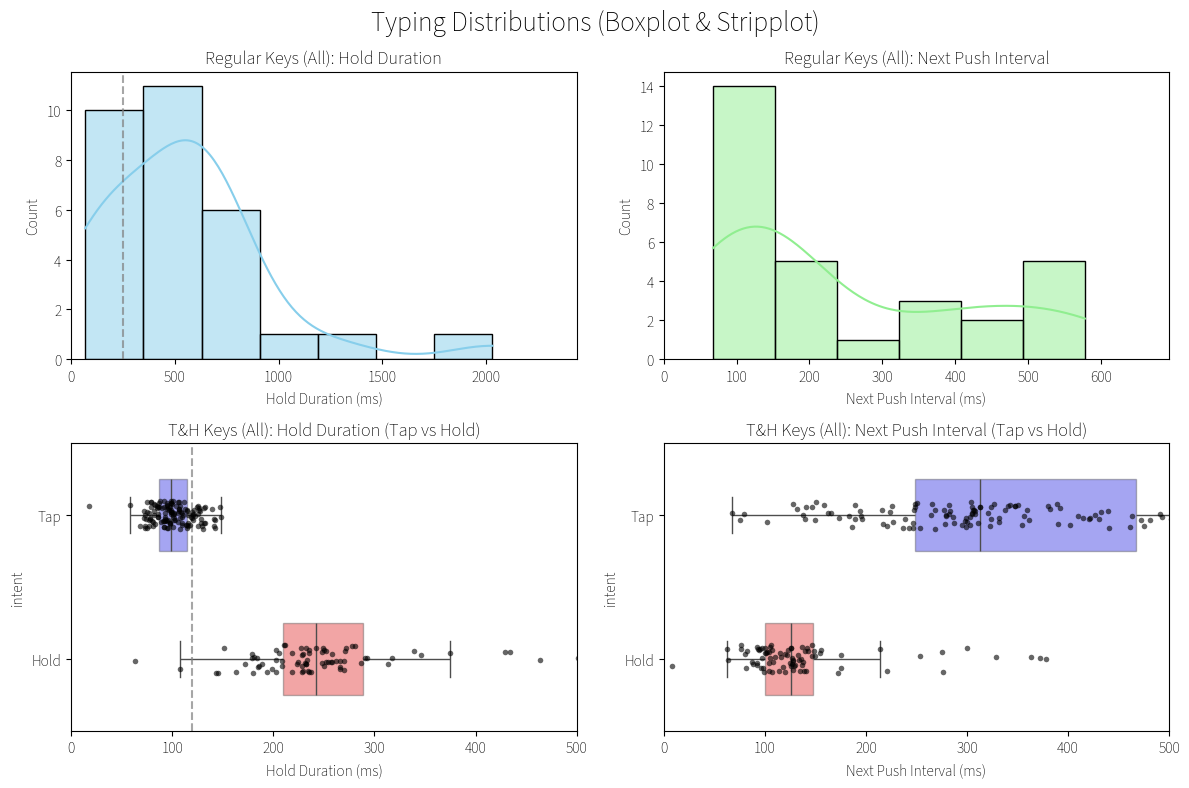

/var/folders/1x/gbcc0yx16s18r3yrbxn3sc4w0000gn/T/ipykernel_75893/1826428578.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_subset, x="hold_duration", y="intent",
/var/folders/1x/gbcc0yx16s18r3yrbxn3sc4w0000gn/T/ipykernel_75893/1826428578.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_subset, x="hold_duration", y="intent",
/var/folders/1x/gbcc0yx16s18r3yrbxn3sc4w0000gn/T/ipykernel_75893/1826428578.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_subset, x="hold_duration", y="intent",



=== THキー個別の統計 (キー別・Tap/Hold別) (ms) ===
3 個のTHキーが見つかりました。


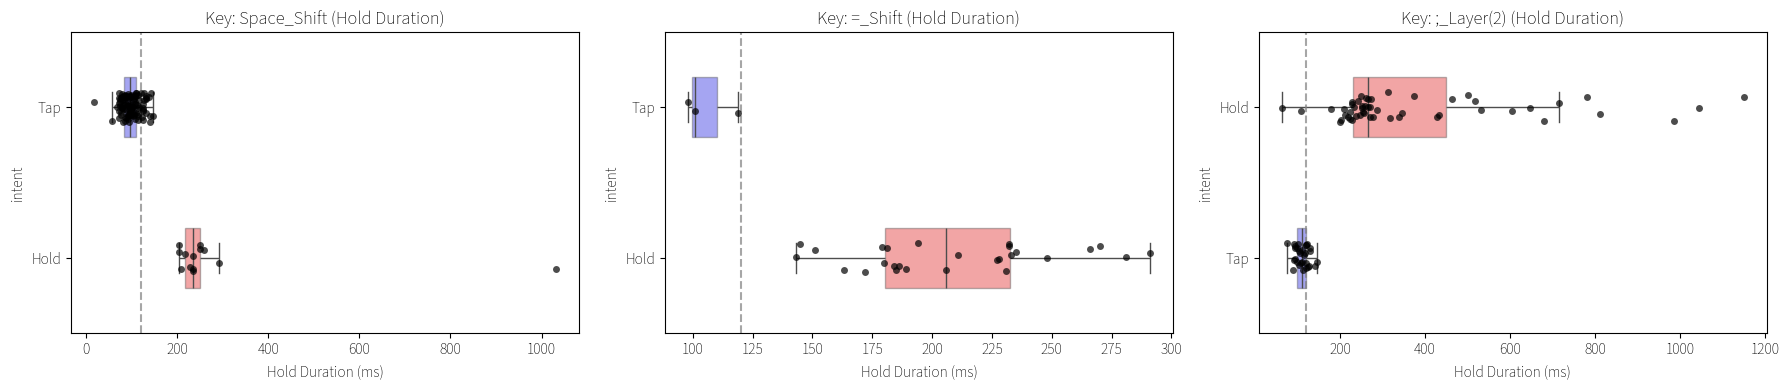

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans JP'


TH_KEYS = [
    "R3,C0", # =_Shift
    "R9,C0", # rshift+space
    "R2,C2", # S_Ctrl
    "R2,C3", # D_Alt
    "R2,C4", # F_WinCmd
    "R7,C1", # J_WinCmd#4
    "R7,C2", # K_Alt#5
    "R7,C3", # L_Ctrl#6
    "R7,C4", # ;_Layer(2)
    "R7,C5", # '_Layer(3)
    "R2,C0", # -_Layer(3)
]

def load_and_preprocess_data(strokes_file, labels_file):
    with open(strokes_file, 'r') as f: strokes = json.load(f)
    with open(labels_file, 'r') as f: labels = json.load(f)

    df = pd.DataFrame(strokes)
    df['intent'] = df['push_ts'].astype(str).map(labels).fillna('Error')
    df = df[df['intent'] != 'Error'].copy()
    df['is_th_key'] = df['id'].isin(TH_KEYS)

    if 'key_name' not in df.columns:
        df['key_name'] = df['id']

    return df

def plot_distributions_boxplot(df):
    df_regular = df[~df["is_th_key"]].copy()
    df_th = df[df["is_th_key"]].copy()


    # Pandasの表示制限を解除（全キーを表示するため）
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)

    # ====== キーごとの統計出力 ======
    print("=== 一般キーの統計 (キー別・打鍵回数順) (ms) ===")
    # キーごとにグループ化し、count(回数), mean(平均), min(最小), max(最大) を算出
    reg_stats = df_regular.groupby("key_name")[["hold_duration", "next_push_interval"]].agg(['count', 'mean', 'min', 'max'])
    # 打鍵回数（count）が多い順にソート
    reg_stats = reg_stats.sort_values(by=("hold_duration", "count"), ascending=False)
    print(reg_stats.round(1))

    print("\n=== THキーの統計 (キー別・Tap/Hold別) (ms) ===")
    th_stats = df_th.groupby(["key_name", "intent"])[["hold_duration", "next_push_interval"]].agg(['count', 'mean', 'min', 'max'])
    print(th_stats.round(1))

    # 表示制限を元に戻す
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')

    # ====== グラフ描画 (Boxplot & Stripplot) ======
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Typing Distributions (Boxplot & Stripplot)", fontsize=18)

    # Plot [0, 0]: 一般キー Hold
    ax = axes[0, 0]
    sns.histplot(data=df_regular, x="hold_duration", kde=True, ax=ax, color="skyblue")
    ax.set_title("Regular Keys (All): Hold Duration")
    ax.set_xlabel("Hold Duration (ms)")
    ax.set_xlim(0, max(df_regular["hold_duration"].max() * 1.2, 200))
    ax.axvline(250, color='gray', linestyle='--', alpha=0.7)

    # Plot [0, 1]: 一般キー Interval
    ax = axes[0, 1]
    sns.histplot(data=df_regular, x="next_push_interval", kde=True, ax=ax, color="lightgreen")
    ax.set_title("Regular Keys (All): Next Push Interval")
    ax.set_xlabel("Next Push Interval (ms)")
    ax.set_xlim(0, max(df_regular["next_push_interval"].max() * 1.2, 200))

    # Plot [1, 0]: THキー Hold (Tap vs Hold)
    ax = axes[1, 0]
    sns.boxplot(data=df_th, x="hold_duration", y="intent", palette={"Tap": "blue", "Hold": "red"},
                width=0.5, boxprops=dict(alpha=0.4), fliersize=0, ax=ax)
    sns.stripplot(data=df_th, x="hold_duration", y="intent", color="black", alpha=0.6, jitter=True, size=4, ax=ax)
    ax.set_title("T&H Keys (All): Hold Duration (Tap vs Hold)")
    ax.set_xlabel("Hold Duration (ms)")
    ax.set_xlim(0, 500)
    ax.axvline(120, color='gray', linestyle='--', alpha=0.7)

    # Plot [1, 1]: THキー Interval (Tap vs Hold)
    ax = axes[1, 1]
    sns.boxplot(data=df_th, x="next_push_interval", y="intent", palette={"Tap": "blue", "Hold": "red"},
                width=0.5, boxprops=dict(alpha=0.4), fliersize=0, ax=ax)
    sns.stripplot(data=df_th, x="next_push_interval", y="intent", color="black", alpha=0.6, jitter=True, size=4, ax=ax)
    ax.set_title("T&H Keys (All): Next Push Interval (Tap vs Hold)")
    ax.set_xlabel("Next Push Interval (ms)")
    ax.set_xlim(0, 500)

    plt.tight_layout()
    plt.show()

    # ====== THキー個別のズームプロット ======
    unique_th_keys = df_th['key_name'].unique()
    n_keys = len(unique_th_keys)
    n_cols = 3
    n_rows = (n_keys + n_cols - 1) // n_cols  # 列数に基づいて行数を計算
    print(f"\n=== THキー個別の統計 (キー別・Tap/Hold別) (ms) ===")
    print(n_keys, "個のTHキーが見つかりました。")

    if n_keys > 0:
        fig_ind, axes_ind = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
        axes_ind = axes_ind.flatten()  # 2次元配列を1次元に変換
        for i in range(n_keys, len(axes_ind)):
            fig_ind.delaxes(axes_ind[i])  # 余分なサブプロットを削除
        for ax, k_name in zip(axes_ind, unique_th_keys):
            df_subset = df_th[df_th['key_name'] == k_name]

            # Boxplot と Stripplot を重ねて描画
            sns.boxplot(data=df_subset, x="hold_duration", y="intent",
                        palette={"Tap": "blue", "Hold": "red"},
                        width=0.4, boxprops=dict(alpha=0.4), fliersize=0, ax=ax)
            sns.stripplot(data=df_subset, x="hold_duration", y="intent",
                          color="black", alpha=0.7, jitter=True, size=5, ax=ax)

            # 120ms と 250ms のライン
            ax.axvline(120, color='gray', linestyle='--', alpha=0.7)

            ax.set_title(f"Key: {k_name} (Hold Duration)")
            #ax.set_xlim(0, 400)
            ax.set_xlabel("Hold Duration (ms)")

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    STROKES_FILE = "../preprocessed/strokes_svm_symb1.json"
    LABELS_FILE = "../preprocessed/labels_svm_symb1.json"

    try:
        df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)
        plot_distributions_boxplot(df_merged)
    except Exception as e:
        print(f"エラーが発生しました: {e}")

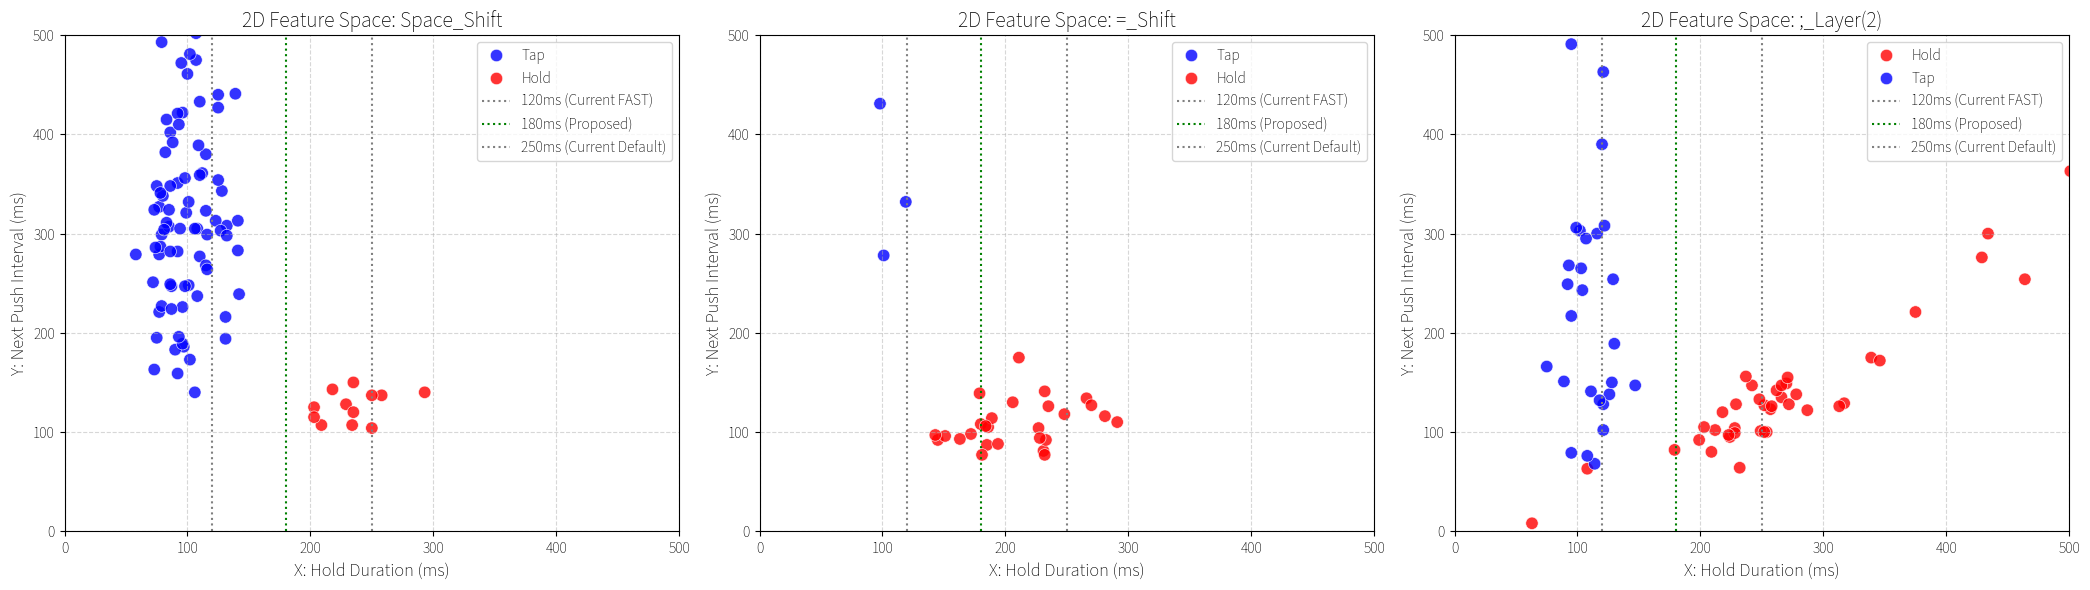

In [9]:
import matplotlib.pyplot as plt


def load_and_preprocess_data(strokes_file, labels_file):
    with open(strokes_file, 'r') as f: strokes = json.load(f)
    with open(labels_file, 'r') as f: labels = json.load(f)

    df = pd.DataFrame(strokes)
    df['intent'] = df['push_ts'].astype(str).map(labels).fillna('Error')
    df = df[df['intent'] != 'Error'].copy()
    df['is_th_key'] = df['id'].isin(TH_KEYS)

    if 'key_name' not in df.columns:
        df['key_name'] = df['id']

    return df

def plot_2d_feature_space(df, n_cols=3):
    df_th = df[df["is_th_key"]].copy()

    unique_th_keys = df_th['key_name'].unique()
    n_keys = len(unique_th_keys)
    n_rows = (n_keys + n_cols - 1) // n_cols  # 列数に基づいて行数を計算

    if n_keys == 0:
        print("T&Hキーのデータがありません。")
        return

    # キーごとに独立した散布図を描画
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
    axes = axes.flatten()  # 2次元配列を1次元に変換
    for i in range(n_keys, len(axes)):
        fig.delaxes(axes[i])  # 余分なサブプロットを削除

    for ax, k_name in zip(axes, unique_th_keys):
        df_subset = df_th[df_th['key_name'] == k_name]

        # 散布図（Scatter Plot）の描画
        sns.scatterplot(
            data=df_subset,
            x="hold_duration",
            y="next_push_interval",
            hue="intent",
            palette={"Tap": "blue", "Hold": "red"},
            alpha=0.8,
            s=80, # ドットのサイズ
            edgecolor="w",
            linewidth=0.5,
            ax=ax
        )

        # 考察用の参照線（現在話題に上がっている閾値）
        ax.axvline(120, color='gray', linestyle=':', label='120ms (Current FAST)')
        ax.axvline(180, color='green', linestyle=':', label='180ms (Proposed)')
        ax.axvline(250, color='gray', linestyle=':', label='250ms (Current Default)')

        ax.set_title(f"2D Feature Space: {k_name}", fontsize=14)
        ax.set_xlabel("X: Hold Duration (ms)", fontsize=12)
        ax.set_ylabel("Y: Next Push Interval (ms)", fontsize=12)

        # 外れ値に引っ張られすぎないように軸の表示範囲を固定
        ax.set_xlim(0, 500)
        ax.set_ylim(0, 500)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    STROKES_FILE = "../preprocessed/strokes_svm_symb1.json"
    LABELS_FILE = "../preprocessed/labels_svm_symb1.json"

    try:
        df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)
        plot_2d_feature_space(df_merged)
    except Exception as e:
        print(f"エラーが発生しました: {e}")

In [10]:
from sklearn.svm import SVC
import numpy as np


SCALE = 1e5

def derive_decision_boundary(df, target_key="R9,C0"):
    # 指定したキーのデータだけを抽出
    df_key = df[df['id'] == target_key].dropna(subset=['next_push_interval'])

    if len(df_key) == 0:
        print(f"キー '{target_key}' のデータが見つかりません。")
        return

    # 特徴量 X(Hold Duration) と Y(Next Push Interval)
    X_features = df_key[['hold_duration', 'next_push_interval']].values

    # ラベル（Hold=1, Tap=-1）
    #y_labels = (df_key['intent'] == 'Hold').astype(int).values.copy()
    #print(f"y_labels (Before): {y_labels}")
    y_labels = np.where(df_key['intent'] == 'Hold', 1, -1)
    print(f"y_labels (After) : {y_labels}")

    # 線形SVMモデルの学習
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_features, y_labels)

    # 係数の抽出
    w1, w2 = clf.coef_[0]
    b = clf.intercept_[0]

    print(f"\n=== 判別式 (Decision Boundary) for {target_key} ===")
    print(f"w1 (Hold Duration)    : {w1*SCALE:.6f}")
    print(f"w2 (Next Interval)    : {w2*SCALE:.6f}")
    print(f"b  (Intercept)        : {b*SCALE:.6f}")
    print(f"判別式: {w1*SCALE:.6f}*X + {w2*SCALE:.6f}*Y + {b*SCALE:.6f} > 0 なら Hold")

    params = {
        "w1n": w1 / w1,
        "w2n": w2 / w1,
        "bn": b / w1
    }
    print(f"正規化された判別式: X + {params['w2n']:.6f}*Y + {params['bn']:.6f} > 0 なら Hold")
    return params


if __name__ == "__main__":
    try:
        df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)
        params = derive_decision_boundary(df_merged, "R9,C0")
        params = derive_decision_boundary(df_merged, "R3,C0")
        params = derive_decision_boundary(df_merged, "R7,C4")
    except Exception as e:
        print(f"エラーが発生しました: {e}")

y_labels (After) : [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1
 -1 -1  1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1 -1 -1  1 -1
 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1]

=== 判別式 (Decision Boundary) for R9,C0 ===
w1 (Hold Duration)    : 1923.480052
w2 (Next Interval)    : -890.500024
b  (Intercept)        : -179197.237288
判別式: 1923.480052*X + -890.500024*Y + -179197.237288 > 0 なら Hold
正規化された判別式: X + -0.462963*Y + -93.163034 > 0 なら Hold
y_labels (After) : [-1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1
  1  1  1  1  1  1]

=== 判別式 (Decision Boundary) for R3,C0 ===
w1 (Hold Duration)    : 968.778898
w2 (Next Interval)    : -907.129332
b  (Intercept)        : 54335.285570
判別式: 968.778898*X + -907.129332*Y + 54335.285570 > 0 なら Hold
正規化された判別式: X + -0.936364

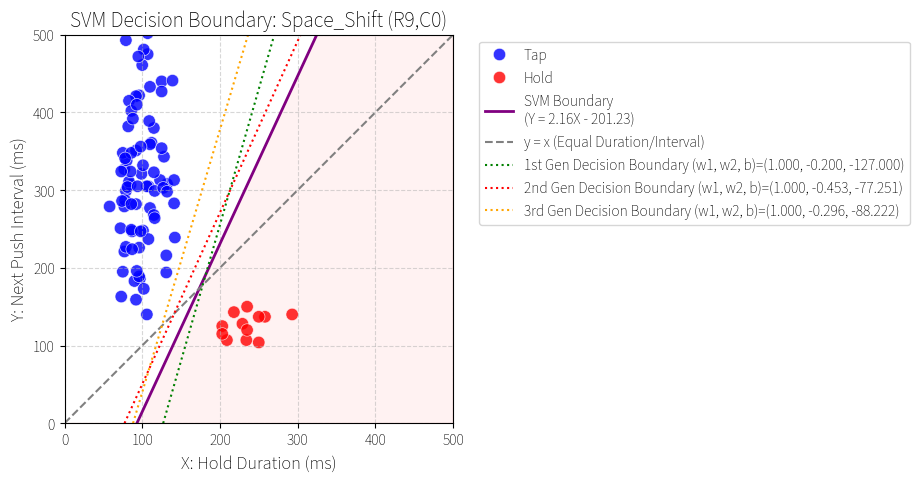

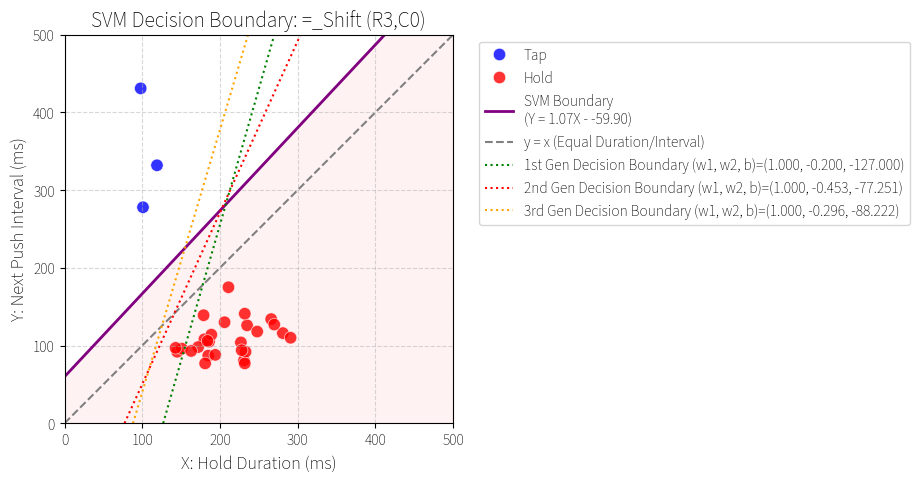

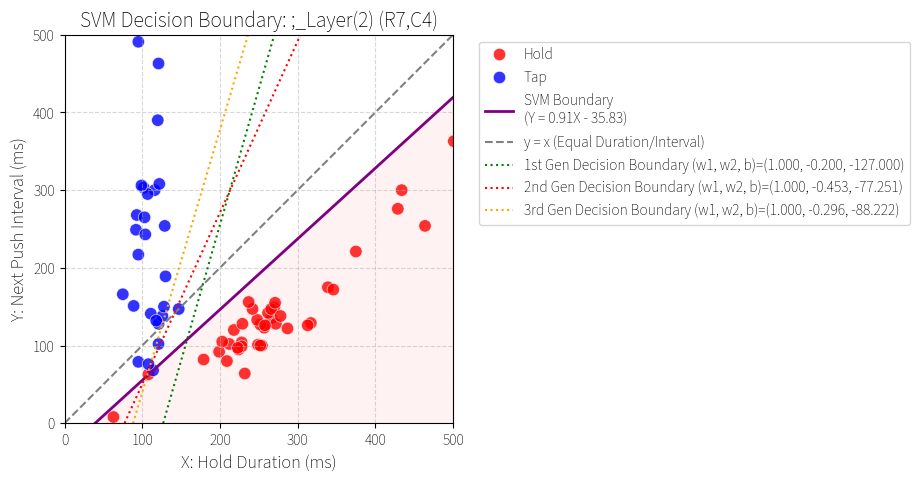

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

def plot_2d_feature_space_with_svm(df, target_id="R9,C0"):
    # データ抽出
    df_key = df[df['id'] == target_id].dropna(subset=['next_push_interval']).copy()

    if len(df_key) == 0:
        print(f"エラー: id='{target_id}' の有効なデータが見つかりません。")
        return

    X_features = df_key[['hold_duration', 'next_push_interval']].values
    y_labels = np.where(df_key['intent'] == 'Hold', 1, -1)

    # 線形SVMモデルの学習
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_features, y_labels)
    w1, w2 = clf.coef_[0]
    b = clf.intercept_[0]
    key_name = df_key['key_name'].iloc[0]

    # ====== グラフ描画 ======
    fig, ax = plt.subplots(figsize=(8, 6))

    # 散布図
    sns.scatterplot(
        data=df_key, x="hold_duration", y="next_push_interval",
        hue="intent", palette={"Tap": "blue", "Hold": "red"},
        alpha=0.8, s=80, edgecolor="w", linewidth=0.5, ax=ax
    )

    # ====== 境界線の描画 ======
    # Xの描画範囲（0〜500）に合わせてYの値を計算
    x_vals = np.array([0, 500])
    if w2 != 0:
        y_vals = (-w1 / w2) * x_vals - (b / w2)
        ax.plot(x_vals, y_vals, color='purple', linestyle='-', linewidth=2,
                label=f'SVM Boundary\n(Y = {-w1/w2:.2f}X - {b/w2:.2f})')

        # Holdの判定領域を薄く塗りつぶす（視覚的アシスト）
        # w2がマイナスの場合、w1*X + w2*Y + b > 0 は Y < ... となる
        if w2 < 0:
            ax.fill_between(x_vals, 0, y_vals, color='red', alpha=0.05)
        else:
            ax.fill_between(x_vals, y_vals, 500, color='red', alpha=0.05)

    # draw x=y
    ax.plot([0, 500], [0, 500], color='gray', linestyle='--', label='y = x (Equal Duration/Interval)')
    # draw reference lines
    ax.plot([127, 270], [0, 500], color='green', linestyle=':', label='1st Gen Decision Boundary (w1, w2, b)=(1.000, -0.200, -127.000)')

    ax.plot([77.251, 303.751], [0, 500], color='red', linestyle=':', label='2nd Gen Decision Boundary (w1, w2, b)=(1.000, -0.453, -77.251)')
    ax.plot([88.222, 236.222], [0, 500], color='orange', linestyle=':', label='3rd Gen Decision Boundary (w1, w2, b)=(1.000, -0.296, -88.222)')

    # 見た目の調整
    ax.set_title(f"SVM Decision Boundary: {key_name} ({target_id})", fontsize=14)
    ax.set_xlabel("X: Hold Duration (ms)", fontsize=12)
    ax.set_ylabel("Y: Next Push Interval (ms)", fontsize=12)
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 500)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# 実行部分（すでにある df_merged を渡してください）

if __name__ == "__main__":
    try:
        df_merged = load_and_preprocess_data(STROKES_FILE, LABELS_FILE)
        plot_2d_feature_space_with_svm(df_merged, "R9,C0")
        plot_2d_feature_space_with_svm(df_merged, "R3,C0")
        plot_2d_feature_space_with_svm(df_merged, "R7,C4")
    except Exception as e:
        print(f"エラーが発生しました: {e}")
